# Phase 3: PCA Dimensionality Reduction

In [1]:
# Setting the directories

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

IMG_SIZE = (128, 128)

_cwd = os.path.abspath(os.getcwd())
BASE_DIR = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'notebooks' else _cwd

PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')
PLOTS_DIR     = os.path.join(BASE_DIR, 'outputs', 'plots')
MODELS_DIR    = os.path.join(BASE_DIR, 'outputs', 'models')
PCA_COMP_DIR  = os.path.join(BASE_DIR, 'outputs', 'pca_components')

In [2]:
# Loading feature matrix

X = np.load(os.path.join(PROCESSED_DIR, 'X.npy'))
y = np.load(os.path.join(PROCESSED_DIR, 'y.npy'))
print(f'Loaded X: {X.shape}  y: {y.shape}')

Loaded X: (442, 16384)  y: (442,)


In [3]:
# Applying PCA transformation

# Standardising feature matrix before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fitting PCA to capture 95% cumulative variance
pca = PCA(n_components=0.95, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)

print(f'Components selected : {pca.n_components_}')
print(f'Variance explained  : {pca.explained_variance_ratio_.sum():.4f}')
print(f'Reduced shape       : {X_pca.shape}')

Components selected : 233
Variance explained  : 0.9501
Reduced shape       : (442, 233)


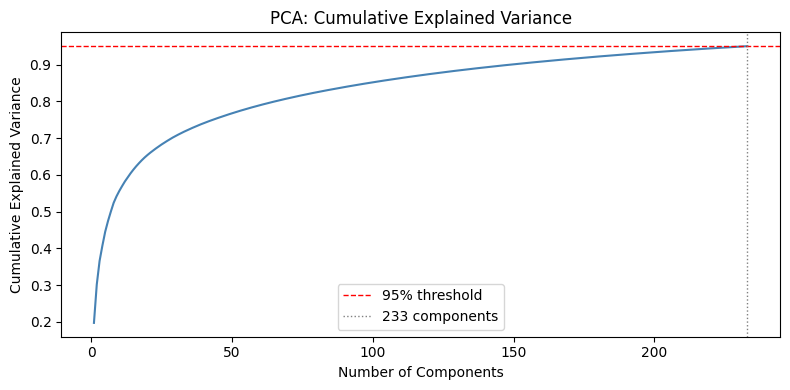

In [4]:
# Saving explained variance curve

cumvar = np.cumsum(pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar, linewidth=1.5, color='steelblue')
ax.axhline(0.95, color='red', linestyle='--', linewidth=1, label='95% threshold')
ax.axvline(pca.n_components_, color='gray', linestyle=':', linewidth=1,
           label=f'{pca.n_components_} components')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA: Cumulative Explained Variance')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'pca_variance_curve.png'), dpi=150)
plt.show()

In [5]:
# Saving transformed dataset and PCA model

np.save(os.path.join(PROCESSED_DIR, 'X_pca.npy'), X_pca)

with open(os.path.join(MODELS_DIR, 'pca_model.pkl'), 'wb') as f:
    pickle.dump({'pca': pca, 'scaler': scaler}, f)

print('Saved X_pca.npy and pca_model.pkl')

Saved X_pca.npy and pca_model.pkl


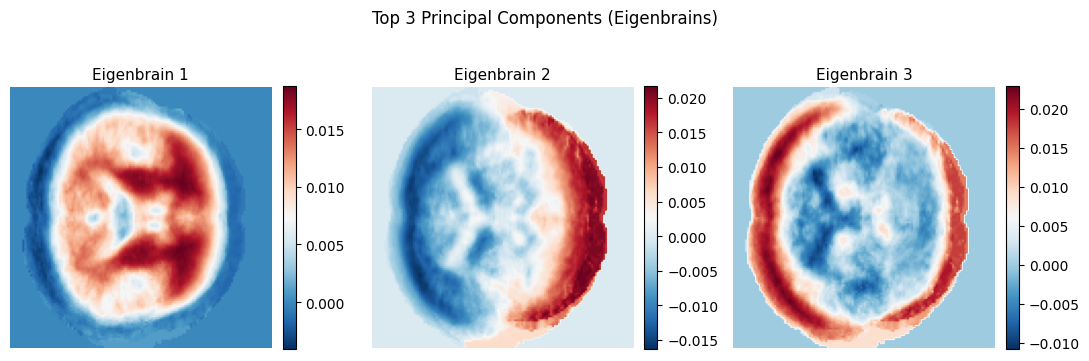

Saved eigenbrain_1.png, eigenbrain_2.png, eigenbrain_3.png


In [6]:
# Visualising eigenbrains

# Plotting top 3 principal components reshaped as brain images
fig, axes = plt.subplots(1, 3, figsize=(11, 4))

for i, ax in enumerate(axes):
    eigenbrain = pca.components_[i].reshape(IMG_SIZE)
    im = ax.imshow(eigenbrain, cmap='RdBu_r')
    ax.set_title(f'Eigenbrain {i + 1}', fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Saving each eigenbrain individually
    fig_s, ax_s = plt.subplots(figsize=(4, 4))
    ax_s.imshow(eigenbrain, cmap='RdBu_r')
    ax_s.set_title(f'Eigenbrain {i + 1}', fontsize=11)
    ax_s.axis('off')
    fig_s.tight_layout()
    fig_s.savefig(os.path.join(PCA_COMP_DIR, f'eigenbrain_{i + 1}.png'), dpi=150)
    plt.close(fig_s)

plt.suptitle('Top 3 Principal Components (Eigenbrains)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'eigenbrains_overview.png'), dpi=150)
plt.show()
print('Saved eigenbrain_1.png, eigenbrain_2.png, eigenbrain_3.png')